In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from robustness_utils import (
    COMBINED_CLASSES,
    DATASET_ROOT,
    DEVICE,
    MODEL_DIR,
    PERTURBATION_100_PERCENT,
    ROAD_CLASSES,
    VISIBILITY_CLASSES,
    evaluate_model,
    load_checkpoint_model,
    load_test_manifest,
    make_loader,
    perturbation_config_from_controls,
    raw_level_from_percent,
    select_best_checkpoint,
)


In [5]:
BEST_CHECKPOINT = select_best_checkpoint(MODEL_DIR)
MODEL, CHECKPOINT_PAYLOAD = load_checkpoint_model(BEST_CHECKPOINT.path)
TEST_FRAME = load_test_manifest(DATASET_ROOT)

print(f"Device: {DEVICE}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Test images: {len(TEST_FRAME)}")
print(f"Checkpoint: {BEST_CHECKPOINT.path}")
print(f"Checkpoint corpus: {BEST_CHECKPOINT.corpus_name}")
print(f"Best valid exact_match_acc: {BEST_CHECKPOINT.valid_exact_match_acc:.4f}")
print(f"Best valid joint_score: {BEST_CHECKPOINT.valid_joint_score:.4f}")
print(f"Best valid loss: {BEST_CHECKPOINT.valid_loss:.4f}")
print("\n100% perturbation ceilings:")
for key, value in PERTURBATION_100_PERCENT.items():
    print(f"- {key}: {value:.4f}")

display(
    TEST_FRAME.groupby(["road", "visibility"])
    .size()
    .rename("images")
    .reset_index()
)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 197MB/s]


Device: cuda
Dataset root: /content/drive/MyDrive/CV final project/rwvc_bdd100k_balanced_300
Test images: 50
Checkpoint: /content/drive/MyDrive/CV final project/models/efficientnet_b0_two_head/train_plus_synth_plus_aug_best.pt
Checkpoint corpus: train_plus_synth_plus_aug
Best valid exact_match_acc: 0.6400
Best valid joint_score: 0.8100
Best valid loss: 1.0853

100% perturbation ceilings:
- noise: 0.2400
- blur: 3.6000
- lighting_dark: 0.8500
- lighting_bright: 0.8500
- occlusion: 0.7000


,road,visibility,images
0,dry,good,9
1,dry,poor,5
2,snow,good,9
3,snow,poor,9
4,wet,good,9
5,wet,poor,9


In [6]:
METRIC_COLUMNS = [
    "loss",
    "road_loss",
    "visibility_loss",
    "road_acc",
    "visibility_acc",
    "joint_score",
    "exact_match_acc",
]
PERCENT_SWEEP = [0, 20, 40, 60, 80, 100]
PERTURBATION_SWEEPS = {
    "noise": [(percent, perturbation_config_from_controls(noise_percent=percent)) for percent in PERCENT_SWEEP],
    "blur": [(percent, perturbation_config_from_controls(blur_percent=percent)) for percent in PERCENT_SWEEP],
    "lighting_dark": [(percent, perturbation_config_from_controls(lighting_percent=-percent)) for percent in PERCENT_SWEEP],
    "lighting_bright": [(percent, perturbation_config_from_controls(lighting_percent=percent)) for percent in PERCENT_SWEEP],
    "occlusion": [(percent, perturbation_config_from_controls(occlusion_percent=percent)) for percent in PERCENT_SWEEP],
}
PERTURBATION_LABELS = {
    "noise": f"noise (0%=0.00, 100%={raw_level_from_percent('noise', 100):.2f} std)",
    "blur": f"blur (0%=0.00, 100%={raw_level_from_percent('blur', 100):.2f} radius)",
    "lighting_dark": f"lighting dark (0%=0.00, 100%=-{raw_level_from_percent('lighting_dark', 100):.2f})",
    "lighting_bright": f"lighting bright (0%=0.00, 100%=+{raw_level_from_percent('lighting_bright', 100):.2f})",
    "occlusion": f"occlusion (0%=0.00, 100%={raw_level_from_percent('occlusion', 100):.2f} fraction)",
}


def raw_value_for_row(perturbation: str, percent: float) -> float:
    if perturbation == "noise":
        return raw_level_from_percent("noise", percent)
    if perturbation == "blur":
        return raw_level_from_percent("blur", percent)
    if perturbation == "lighting_dark":
        return -raw_level_from_percent("lighting_dark", percent)
    if perturbation == "lighting_bright":
        return raw_level_from_percent("lighting_bright", percent)
    if perturbation == "occlusion":
        return raw_level_from_percent("occlusion", percent)
    raise KeyError(perturbation)


def plot_confusion_matrix(y_true, y_pred, labels, title):
    matrix = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))
    display_labels = [label.replace(" / ", "\n") for label in labels] if len(labels) > 3 else labels
    fig, ax = plt.subplots(figsize=(7.5, 6.0) if len(labels) > 3 else (5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=display_labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return matrix


def run_robustness_sweeps(frame: pd.DataFrame):
    rows = []
    predictions_by_key = {}
    for perturbation_name, sweep in PERTURBATION_SWEEPS.items():
        for percent, config in sweep:
            loader = make_loader(frame, perturbation=config, batch_size=16)
            metrics, predictions = evaluate_model(MODEL, loader)
            row = {
                "perturbation": perturbation_name,
                "percent": percent,
                "raw_value": raw_value_for_row(perturbation_name, percent),
                "noise_std": config.noise_std,
                "blur_radius": config.blur_radius,
                "lighting_delta": config.lighting_delta,
                "occlusion_fraction": config.occlusion_fraction,
            }
            row.update(metrics)
            rows.append(row)
            predictions_by_key[(perturbation_name, percent)] = predictions
    return pd.DataFrame(rows), predictions_by_key


def display_metric_tables(results: pd.DataFrame):
    for perturbation_name in results["perturbation"].unique():
        subset = results.loc[results["perturbation"] == perturbation_name].copy()
        subset = subset.sort_values("percent")
        print(f"\n=== {perturbation_name} ===")
        display(subset[["percent", "raw_value", *METRIC_COLUMNS]])


def plot_metric_sweeps(results: pd.DataFrame):
    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))
    axes = axes.flatten()
    for plot_idx, metric in enumerate(METRIC_COLUMNS):
        ax = axes[plot_idx]
        for perturbation_name in results["perturbation"].unique():
            subset = results.loc[results["perturbation"] == perturbation_name].sort_values("percent")
            ax.plot(subset["percent"], subset[metric], marker="o", label=PERTURBATION_LABELS[perturbation_name])
        ax.set_title(metric)
        ax.set_xlabel("perturbation percent (0%=floor, 100%=calibrated ceiling)")
        ax.set_ylabel(metric)
        ax.set_xlim(0, 100)
        ax.grid(True, alpha=0.3)
    axes[-1].axis("off")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=1, bbox_to_anchor=(0.5, -0.01), fontsize=9)
    fig.suptitle("Robustness sweeps with calibrated perturbation floors and ceilings", y=1.02)
    plt.tight_layout(rect=(0, 0.08, 1, 0.98))
    plt.show()


def worst_case_rows(results: pd.DataFrame):
    picked = []
    for perturbation_name in results["perturbation"].unique():
        subset = results.loc[results["perturbation"] == perturbation_name].copy()
        subset = subset.sort_values(["exact_match_acc", "joint_score", "loss"], ascending=[True, True, False])
        picked.append(subset.iloc[0])
    return pd.DataFrame(picked).reset_index(drop=True)


In [7]:
robustness_results, robustness_predictions = run_robustness_sweeps(TEST_FRAME)
robustness_results = robustness_results.sort_values(["perturbation", "percent"]).reset_index(drop=True)
display(robustness_results)


,perturbation,percent,raw_value,noise_std,blur_radius,lighting_delta,occlusion_fraction,loss,road_loss,visibility_loss,road_acc,visibility_acc,joint_score,exact_match_acc
0,blur,0,0.000,0.000,0.00,0.00,0.00,1.050961,0.661925,0.389036,0.70,0.84,0.77,0.56
1,blur,20,0.720,0.000,0.72,0.00,0.00,1.086698,0.681566,0.405132,0.68,0.82,0.75,0.54
2,blur,40,1.440,0.000,1.44,0.00,0.00,1.145241,0.698475,0.446766,0.68,0.84,0.76,0.56
3,blur,60,2.160,0.000,2.16,0.00,0.00,1.244595,0.706723,0.537872,0.70,0.76,0.73,0.54
4,blur,80,2.880,0.000,2.88,0.00,0.00,1.435985,0.738621,0.697364,0.70,0.74,0.72,0.54
5,blur,100,3.600,0.000,3.60,0.00,0.00,1.586802,0.788085,0.798717,0.66,0.74,0.70,0.52
6,lighting_bright,0,0.000,0.000,0.00,0.00,0.00,1.050961,0.661925,0.389036,0.70,0.84,0.77,0.56
7,lighting_bright,20,0.170,0.000,0.00,0.17,0.00,1.002337,0.664454,0.337883,0.74,0.86,0.80,0.64
8,lighting_bright,40,0.340,0.000,0.00,0.34,0.00,1.024364,0.670968,0.353396,0.74,0.86,0.80,0.62
9,lighting_bright,60,0.510,0.000,0.00,0.51,0.00,1.104470,0.715668,0.388802,0.72,0.84,0.78,0.60



=== blur ===


,percent,raw_value,loss,road_loss,visibility_loss,road_acc,visibility_acc,joint_score,exact_match_acc
0,0,0.00,1.050961,0.661925,0.389036,0.70,0.84,0.77,0.56
1,20,0.72,1.086698,0.681566,0.405132,0.68,0.82,0.75,0.54
2,40,1.44,1.145241,0.698475,0.446766,0.68,0.84,0.76,0.56
3,60,2.16,1.244595,0.706723,0.537872,0.70,0.76,0.73,0.54
4,80,2.88,1.435985,0.738621,0.697364,0.70,0.74,0.72,0.54
5,100,3.60,1.586802,0.788085,0.798717,0.66,0.74,0.70,0.52



=== lighting_bright ===


,percent,raw_value,loss,road_loss,visibility_loss,road_acc,visibility_acc,joint_score,exact_match_acc
6,0,0.00,1.050961,0.661925,0.389036,0.70,0.84,0.77,0.56
7,20,0.17,1.002337,0.664454,0.337883,0.74,0.86,0.80,0.64
8,40,0.34,1.024364,0.670968,0.353396,0.74,0.86,0.80,0.62
9,60,0.51,1.104470,0.715668,0.388802,0.72,0.84,0.78,0.60
10,80,0.68,1.104735,0.705124,0.399612,0.70,0.84,0.77,0.58
11,100,0.85,1.087323,0.696665,0.390658,0.70,0.86,0.78,0.60



=== lighting_dark ===


,percent,raw_value,loss,road_loss,visibility_loss,road_acc,visibility_acc,joint_score,exact_match_acc
12,0,-0.00,1.050961,0.661925,0.389036,0.70,0.84,0.77,0.56
13,20,-0.17,1.070704,0.724243,0.346461,0.66,0.84,0.75,0.52
14,40,-0.34,1.091376,0.748979,0.342398,0.62,0.82,0.72,0.48
15,60,-0.51,1.223310,0.836226,0.387084,0.68,0.82,0.75,0.56
16,80,-0.68,1.474356,1.047401,0.426955,0.58,0.78,0.68,0.42
17,100,-0.85,1.718721,1.229216,0.489506,0.48,0.82,0.65,0.40



=== noise ===


,percent,raw_value,loss,road_loss,visibility_loss,road_acc,visibility_acc,joint_score,exact_match_acc
18,0,0.000,1.050961,0.661925,0.389036,0.70,0.84,0.77,0.56
19,20,0.048,0.940609,0.633370,0.307240,0.76,0.86,0.81,0.66
20,40,0.096,1.177264,0.766185,0.411079,0.66,0.78,0.72,0.52
21,60,0.144,1.649233,0.939671,0.709561,0.60,0.68,0.64,0.46
22,80,0.192,1.876693,1.105598,0.771095,0.38,0.54,0.46,0.28
23,100,0.240,1.805308,1.116318,0.688991,0.32,0.48,0.40,0.16



=== occlusion ===


,percent,raw_value,loss,road_loss,visibility_loss,road_acc,visibility_acc,joint_score,exact_match_acc
24,0,0.00,1.050961,0.661925,0.389036,0.70,0.84,0.77,0.56
25,20,0.14,1.061500,0.695604,0.365896,0.74,0.88,0.81,0.62
26,40,0.28,1.173028,0.756251,0.416777,0.72,0.82,0.77,0.56
27,60,0.42,1.192858,0.771670,0.421189,0.72,0.80,0.76,0.56
28,80,0.56,1.275690,0.798774,0.476916,0.64,0.76,0.70,0.50
29,100,0.70,1.412710,0.882587,0.530123,0.62,0.72,0.67,0.50


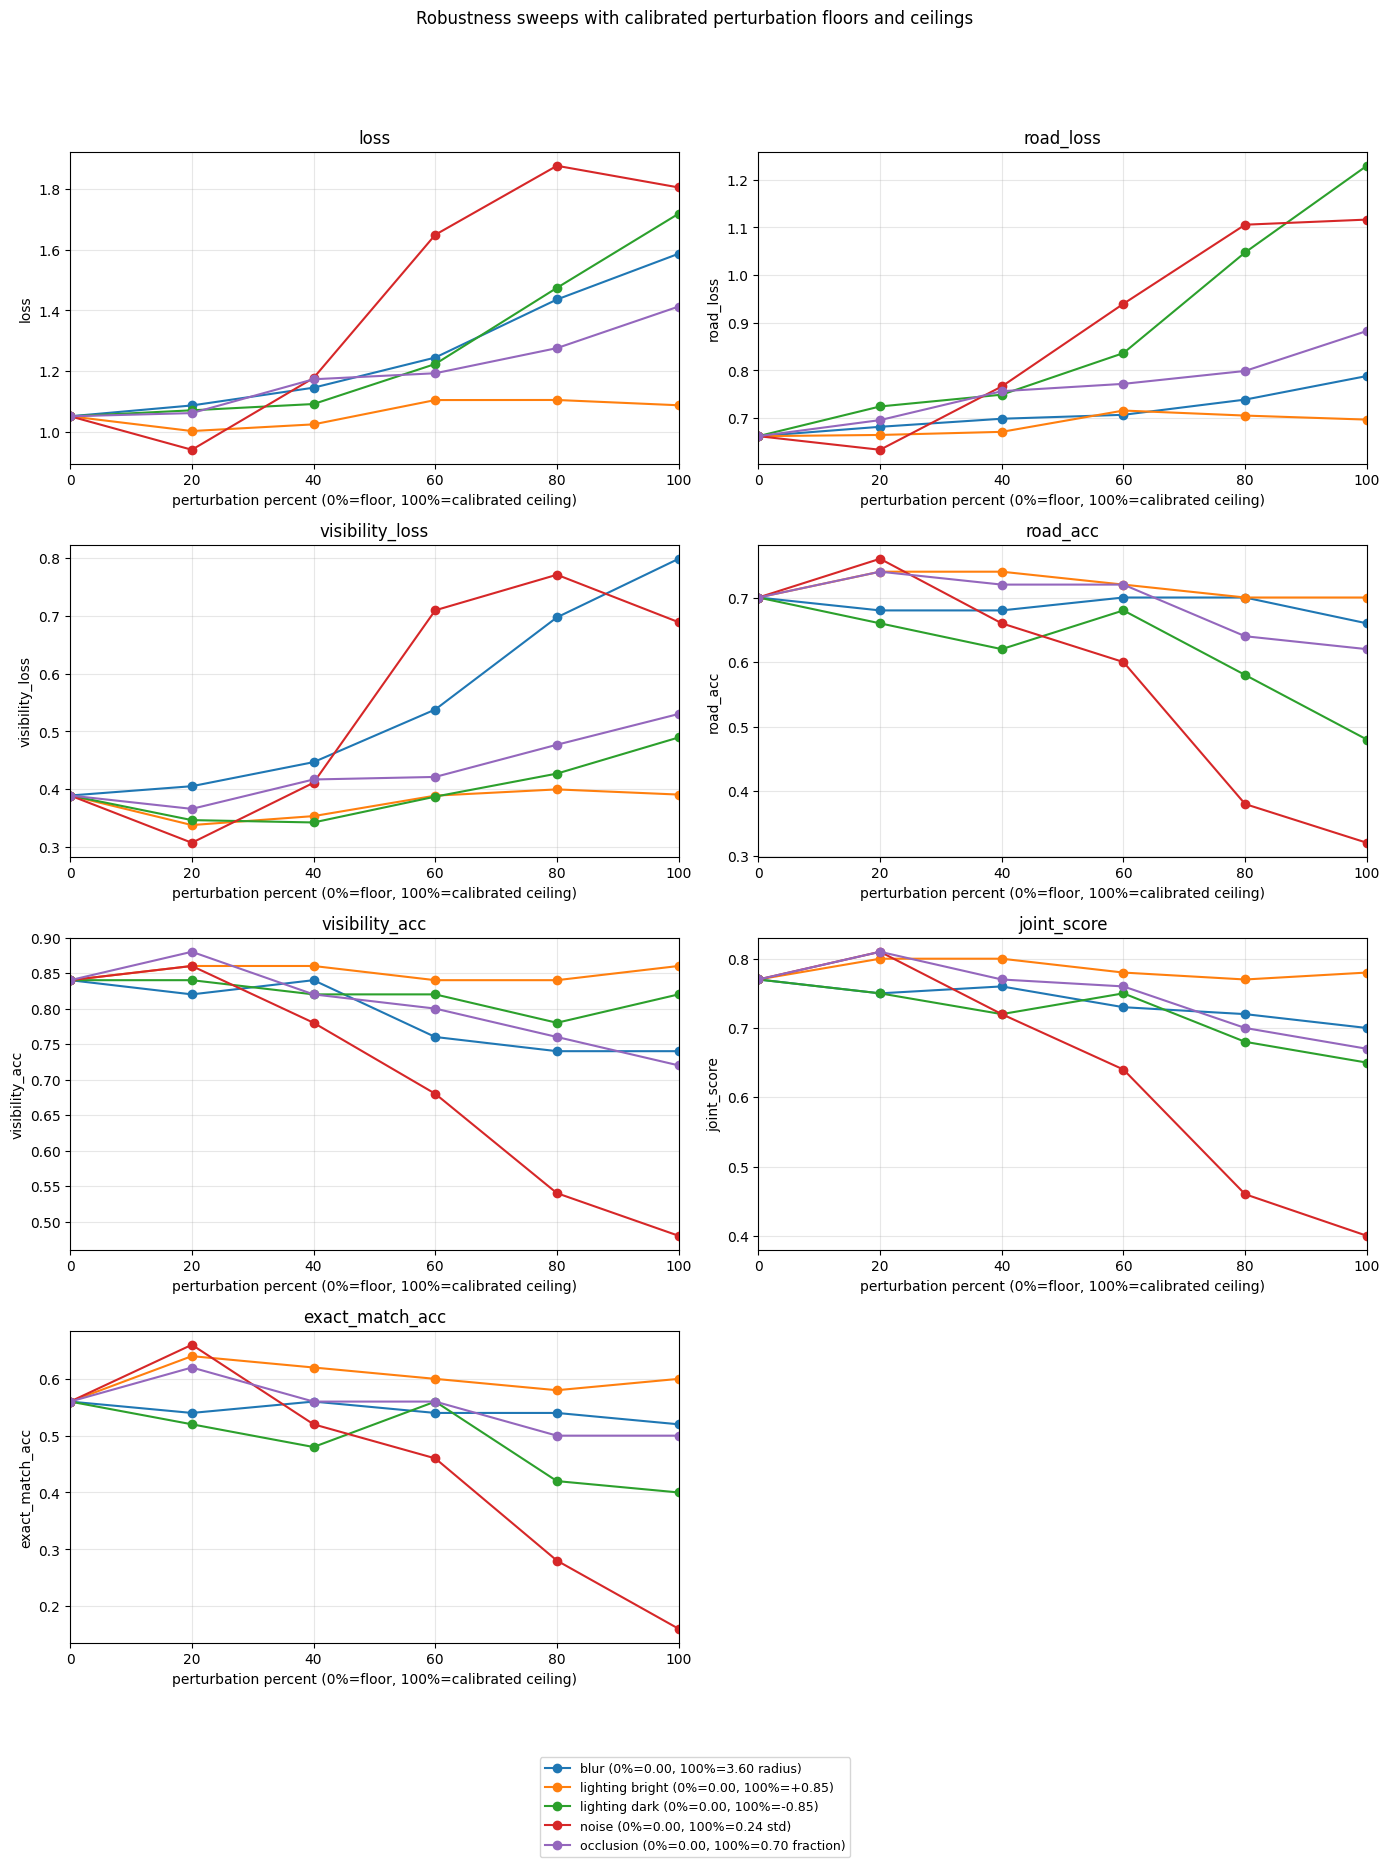

In [8]:
display_metric_tables(robustness_results)
plot_metric_sweeps(robustness_results)


In [9]:
worst_cases = worst_case_rows(robustness_results)
print("Worst-case percent per perturbation (by exact_match_acc, then joint_score, then loss):")
display(worst_cases[["perturbation", "percent", "raw_value", *METRIC_COLUMNS]])


Worst-case percent per perturbation (by exact_match_acc, then joint_score, then loss):


,perturbation,percent,raw_value,loss,road_loss,visibility_loss,road_acc,visibility_acc,joint_score,exact_match_acc
0,blur,100,3.60,1.586802,0.788085,0.798717,0.66,0.74,0.70,0.52
1,lighting_bright,0,0.00,1.050961,0.661925,0.389036,0.70,0.84,0.77,0.56
2,lighting_dark,100,-0.85,1.718721,1.229216,0.489506,0.48,0.82,0.65,0.40
3,noise,100,0.24,1.805308,1.116318,0.688991,0.32,0.48,0.40,0.16
4,occlusion,100,0.70,1.412710,0.882587,0.530123,0.62,0.72,0.67,0.50


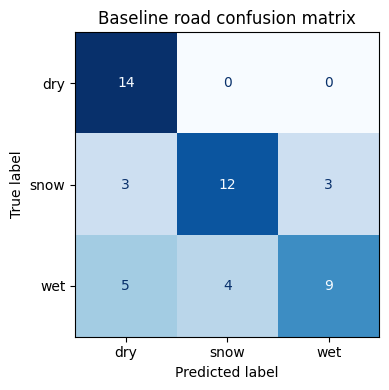

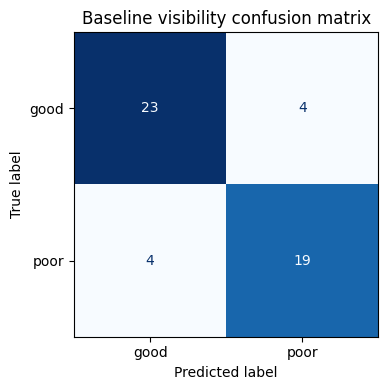

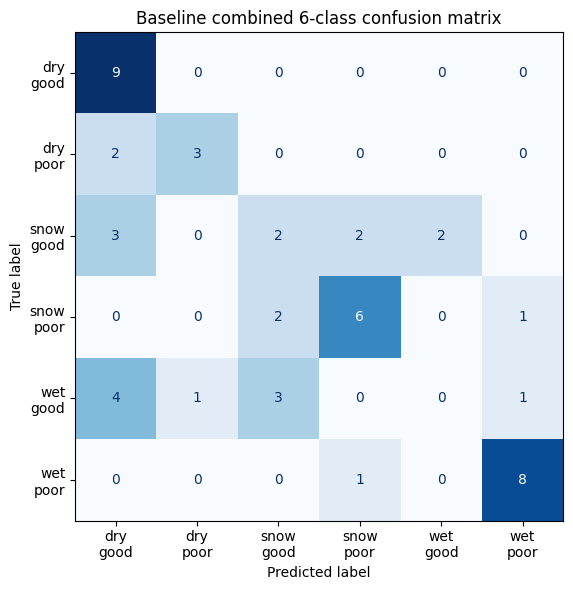

In [10]:
baseline_predictions = robustness_predictions[("noise", 0)]
_ = plot_confusion_matrix(
    baseline_predictions["road_true"],
    baseline_predictions["road_pred"],
    ROAD_CLASSES,
    "Baseline road confusion matrix",
)
_ = plot_confusion_matrix(
    baseline_predictions["visibility_true"],
    baseline_predictions["visibility_pred"],
    VISIBILITY_CLASSES,
    "Baseline visibility confusion matrix",
)
_ = plot_confusion_matrix(
    baseline_predictions["combined_true"],
    baseline_predictions["combined_pred"],
    COMBINED_CLASSES,
    "Baseline combined 6-class confusion matrix",
)


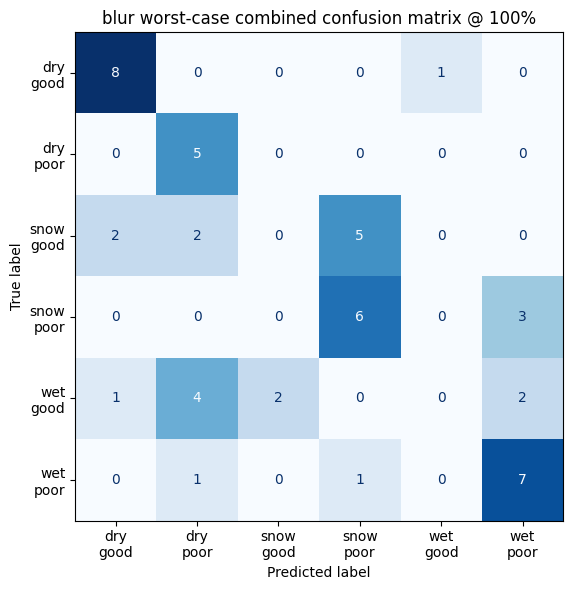

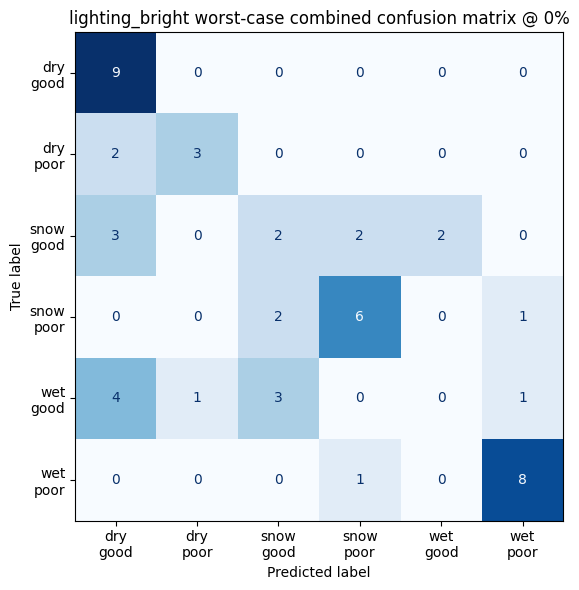

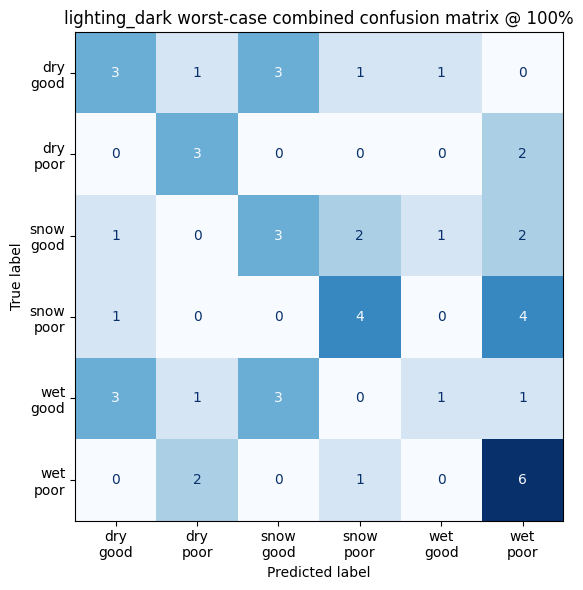

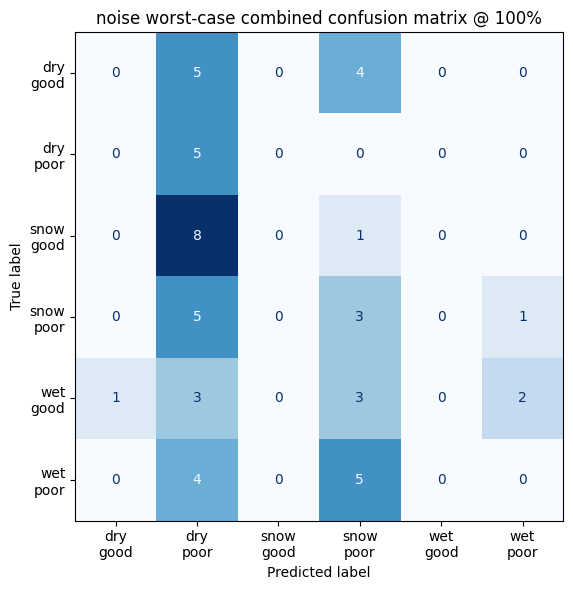

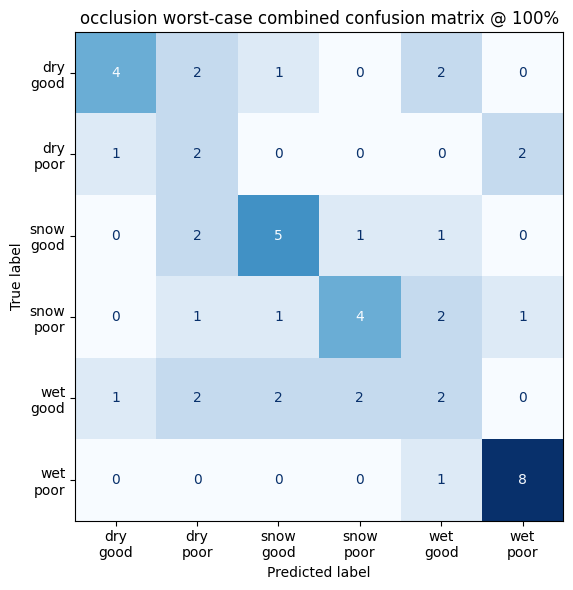

In [11]:
for row in worst_cases.itertuples(index=False):
    predictions = robustness_predictions[(row.perturbation, row.percent)]
    _ = plot_confusion_matrix(
        predictions["combined_true"],
        predictions["combined_pred"],
        COMBINED_CLASSES,
        f"{row.perturbation} worst-case combined confusion matrix @ {row.percent}%",
    )
